Dataset Loaded. Shape: (920, 16)
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4  

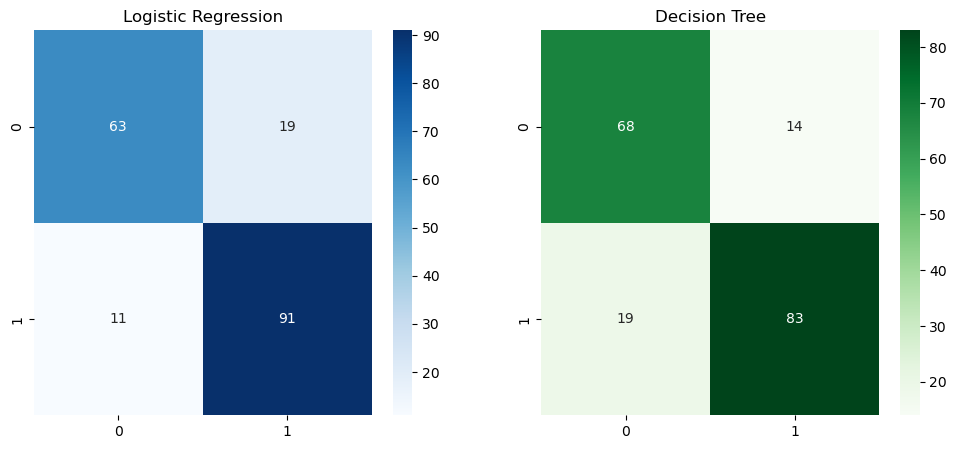

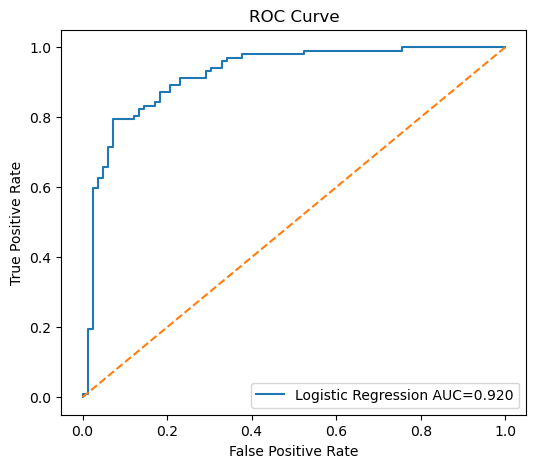


Top Decision Tree Features:
                feature  importance
12      cp_asymptomatic    0.447667
2                  chol    0.102458
0                   age    0.096123
4               oldpeak    0.080270
10  dataset_Switzerland    0.059615
3               thalach    0.047146
6                 sex_F    0.035256
5                    ca    0.025756
7                 sex_M    0.025451
16            fbs_False    0.021896


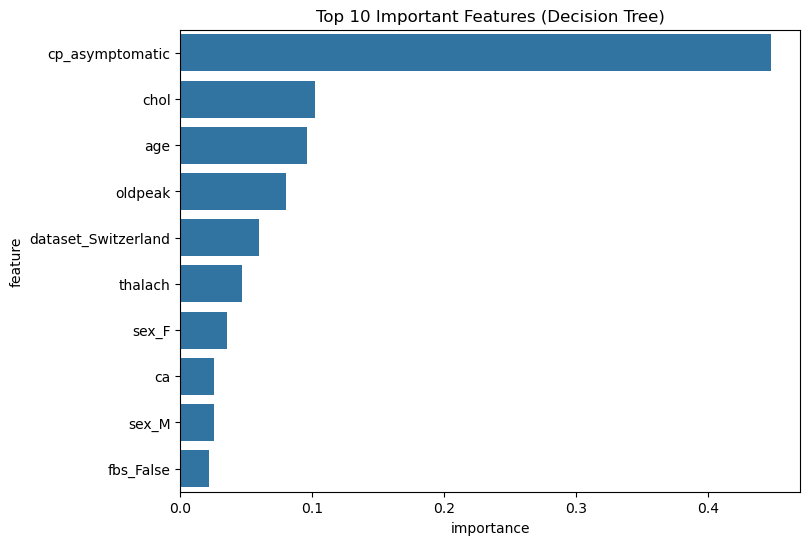

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier


dataset_path = "/Users/shahzorali/Downloads/heart_disease_uci.csv"
df = pd.read_csv(dataset_path)

print("Dataset Loaded. Shape:", df.shape)
print(df.head())


df.rename(columns={"thalch": "thalach", "num": "target"}, inplace=True)


df["target"] = (df["target"] > 0).astype(int)


df.drop(columns=["id"], inplace=True)


numeric_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_features.remove("target")

categorical_features = df.select_dtypes(include=["object"]).columns.tolist()

print("\nNumeric Features:", numeric_features)
print("Categorical Features:", categorical_features)


# Fill numeric missing values with median
for col in numeric_features:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values safely
for col in categorical_features:
    if df[col].nunique() == 0 or df[col].dropna().empty:
        df[col] = df[col].fillna("Unknown")
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

df["sex"] = df["sex"].replace({"Male": "M", "Female": "F"})
df["fbs"] = df["fbs"].replace({True: "True", False: "False"})
df["exang"] = df["exang"].replace({True: "True", False: "False"})


X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


#  PREPROCESSING PIPELINE

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


lr_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('clf', LogisticRegression(max_iter=300))
])

dt_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('clf', DecisionTreeClassifier(max_depth=5))
])

# TRAIN
lr_pipeline.fit(X_train, y_train)
dt_pipeline.fit(X_train, y_train)

# PREDICT
lr_pred = lr_pipeline.predict(X_test)
dt_pred = dt_pipeline.predict(X_test)

#  EVALUATION

acc_lr = accuracy_score(y_test, lr_pred)
acc_dt = accuracy_score(y_test, dt_pred)

print("\nLogistic Regression Accuracy:", acc_lr)
print("Decision Tree Accuracy:", acc_dt)

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_lr = confusion_matrix(y_test, lr_pred)
cm_dt = confusion_matrix(y_test, dt_pred)

sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Logistic Regression")

sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title("Decision Tree")

plt.show()


lr_probs = lr_pipeline.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, lr_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression AUC={roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

ohe = dt_pipeline.named_steps["preprocess"].named_transformers_["cat"]
cat_cols = ohe.get_feature_names_out(categorical_features)

all_features = numeric_features + list(cat_cols)
importances = dt_pipeline.named_steps["clf"].feature_importances_

fi_df = pd.DataFrame({"feature": all_features, "importance": importances})
fi_df = fi_df.sort_values("importance", ascending=False)

print("\nTop Decision Tree Features:")
print(fi_df.head(10))

plt.figure(figsize=(8, 6))
sns.barplot(data=fi_df.head(10), x="importance", y="feature")
plt.title("Top 10 Important Features (Decision Tree)")
plt.show()
